## 1.Introduction

This project analyzes Medicare supplier data for orthotics and prosthetics (O&P) services using data retrieved directly from the CMS public API. The goal of this analysis is to better understand how O&P services are distributed across suppliers and states, how service volume relates to Medicare reimbursement, and which procedures and regions account for the largest share of activity. Because orthotics and prosthetics play an important role in rehabilitation, mobility support, and long-term patient care, understanding service patterns and payment structures is valuable for both healthcare planning and industry analysis.

The primary audience for this analysis is our investment team as we evaluate expansion opportunities in the orthotics and prosthetics (O&P) sector. Following our acquisition of an infrastructure company operating in the O&P market, we are assessing the potential to acquire independent O&P clinics and consolidate them into a larger platform through a roll-up strategy. By examining service volume, reimbursement patterns, and geographic variation, this project aims to provide insights into how O&P services are delivered and reimbursed across the United States. These insights help identify high-demand regions, areas of market fragmentation, and potential targets for clinic consolidation.

This analysis is motivated by the need to better understand the relationship between service utilization and Medicare payment structures within the O&P market. Public healthcare datasets are often large and complex, and meaningful interpretation requires careful data cleaning, validation, and exploratory analysis. Using API-based data retrieval ensures that the analysis is reproducible and scalable. Subsequent data quality checks, exploratory data analysis, and feature engineering steps are performed to uncover patterns in service delivery, supplier behavior, and reimbursement dynamics. Together, these steps provide a comprehensive overview of the O&P service landscape within the Medicare system and support data-driven decision-making as we evaluate potential industry consolidation opportunities.


## 2 Proper Use of API

The main dataset for this project is retrieved directly from the CMS Data API.  
To ensure full data coverage, pagination is implemented using a `while` loop with `size` and `offset` parameters.

We specifically filter for HCPCS codes starting with "L", which correspond to Orthotics & Prosthetics services.  
This approach ensures that the dataset is pulled dynamically from the API rather than downloaded manually.


### Notes on the API pull (documentation)

- **Endpoint**: CMS Public Data API dataset `1746a83e-bb65-4300-8e02-21edbab77c6b`
- **Pagination**: the API returns a limited number of rows per request, so we loop with `offset += size` until an empty page is returned.
- **Filter**: we keep only HCPCS codes that **start with "L"**, which correspond to Orthotics & Prosthetics (O&P).
- **Output**: each row is a **supplier × HCPCS code** record (not “one row per supplier”). This is why supplier-level analysis requires `groupby("Suplr_NPI")`.


In [1]:
# %pip install requests

import requests

supplier_url = "https://data.cms.gov/data-api/v1/dataset/1746a83e-bb65-4300-8e02-21edbab77c6b/data"

sample = requests.get(supplier_url, params={"size": 1, "offset": 0}, timeout=60).json()
row = sample[0] if isinstance(sample, list) else sample.get("results", [{}])[0]

print("Sample keys:", list(row.keys())[:40])


Sample keys: ['Suplr_NPI', 'Suplr_Prvdr_Last_Name_Org', 'Suplr_Prvdr_First_Name', 'Suplr_Prvdr_MI', 'Suplr_Prvdr_Crdntls', 'Suplr_Prvdr_Ent_Cd', 'Suplr_Prvdr_St1', 'Suplr_Prvdr_St2', 'Suplr_Prvdr_City', 'Suplr_Prvdr_State_Abrvtn', 'Suplr_Prvdr_State_FIPS', 'Suplr_Prvdr_Zip5', 'Suplr_Prvdr_RUCA_Cat', 'Suplr_Prvdr_RUCA', 'Suplr_Prvdr_RUCA_Desc', 'Suplr_Prvdr_Cntry', 'Suplr_Prvdr_Spclty_Cd', 'Suplr_Prvdr_Spclty_Desc', 'Suplr_Prvdr_Spclty_Srce', 'RBCS_Lvl', 'RBCS_Id', 'RBCS_Desc', 'HCPCS_Cd', 'HCPCS_Desc', 'Suplr_Rentl_Ind', 'Tot_Suplr_Benes', 'Tot_Suplr_Clms', 'Tot_Suplr_Srvcs', 'Avg_Suplr_Sbmtd_Chrg', 'Avg_Suplr_Mdcr_Alowd_Amt', 'Avg_Suplr_Mdcr_Pymt_Amt', 'Avg_Suplr_Mdcr_Stdzd_Amt']


In [2]:
import requests
import pandas as pd

supplier_url = "https://data.cms.gov/data-api/v1/dataset/1746a83e-bb65-4300-8e02-21edbab77c6b/data"

def fetch_all_op_suppliers(base_url, size=5000):
    """Fetch all Orthotics & Prosthetics (O&P) supplier records via CMS API.

    Parameters
    ----------
    base_url : str
        CMS dataset endpoint.
    size : int
        Page size for each API call.

    Returns
    -------
    pd.DataFrame
        Concatenated results across all pages (supplier × HCPCS rows).
    """
    all_rows = []
    offset = 0  # pagination offset (row index)

    while True:  # keep requesting pages until an empty page is returned
        params = {
            "size": size,
            "offset": offset,

            # filter for O&P HCPCS codes
            "filter[condition][path]": "HCPCS_Cd",
            "filter[condition][operator]": "STARTS_WITH",
            "filter[condition][value]": "L"
        }

        r = requests.get(base_url, params=params, timeout=60)
        r.raise_for_status()

        data = r.json()
        rows = data if isinstance(data, list) else data.get("results", [])

        print(f"offset={offset}, fetched={len(rows)}")

        if not rows:
            break

        all_rows.extend(rows)
        offset += size

    return pd.DataFrame(all_rows)

df = fetch_all_op_suppliers(supplier_url)

print("Final dataset shape:", df.shape)
print("Unique suppliers:", df["Suplr_NPI"].nunique())

df.head()


offset=0, fetched=5000
offset=5000, fetched=5000
offset=10000, fetched=5000
offset=15000, fetched=5000
offset=20000, fetched=5000
offset=25000, fetched=5000
offset=30000, fetched=5000
offset=35000, fetched=4697
offset=40000, fetched=0
Final dataset shape: (39697, 32)
Unique suppliers: 8229


,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,...,HCPCS_Cd,HCPCS_Desc,Suplr_Rentl_Ind,Tot_Suplr_Benes,Tot_Suplr_Clms,Tot_Suplr_Srvcs,Avg_Suplr_Sbmtd_Chrg,Avg_Suplr_Mdcr_Alowd_Amt,Avg_Suplr_Mdcr_Pymt_Amt,Avg_Suplr_Mdcr_Stdzd_Amt
0,1003150723,"Graymont Equipment Distribution, Llc",,,,O,1622 W Carroll Ave,,Chicago,IL,...,L0120,"Cervical, flexible, non-adjustable, prefabrica...",N,17,17,17,73.882352941,30.22,23.684117647,24.780588235
1,1003835141,"Campbell Clinic, Pc",,,,O,1400 S Germantown Rd,,Germantown,TN,...,L0120,"Cervical, flexible, non-adjustable, prefabrica...",N,37,37,37,32.486486486,31.911351351,23.112972973,22.905675676
2,1013068188,"Orthopedic Associates Of Port Huron, P.C.",,,,O,940 River Centre Dr,,Port Huron,MI,...,L0120,"Cervical, flexible, non-adjustable, prefabrica...",N,91,91,91,37,30.309450549,20.885384615,21.939010989
3,1033212600,Yanke Bionics Inc,,,,O,303 W Exchange St,,Akron,OH,...,L0120,"Cervical, flexible, non-adjustable, prefabrica...",N,22,22,22,39.436363636,30.33,23.77,24.78
4,1033490776,"Psi Premier Specialties, Inc.",,,,O,1825 Troup Hwy,,Tyler,TX,...,L0120,"Cervical, flexible, non-adjustable, prefabrica...",N,19,19,19,32.127368421,28.354736842,22.228421053,24.79


### API Retrieval Summary

The dataset was successfully retrieved from the CMS Data API using pagination and filtering. By applying a filter for HCPCS codes that start with the letter "L" (which correspond to Orthotics & Prosthetics services), the API returned all relevant supplier-level records. A `while` loop with `size` and `offset` parameters was used to iteratively download the full dataset while respecting API limits.

In total, **39,697 rows** and **32 columns** were retrieved, representing O&P-related services provided by **8,229 unique suppliers** across the United States. Each row corresponds to a supplier–procedure combination and includes information on service volume, number of beneficiaries, and Medicare reimbursement amounts. The successful retrieval confirms that the API pipeline is working correctly and that the dataset is sufficiently large for meaningful exploratory analysis and feature engineering.

This API-based approach ensures that the data collection process is reproducible, scalable, and aligned with best practices for working with large public healthcare datasets.


## 3 Data Quality Checks

Before analysis, we verify the quality and structure of the dataset retrieved from the CMS API.  
We check for missing values, data types, duplicates, and unusual values to ensure the data is reliable for further analysis.


In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

# --- Schema harmonization (make downstream analysis robust) ---
# The CMS API sometimes returns *supplier totals* and *averages* with slightly different column names.
# This notebook expects a mix of legacy names (Tot_Srvcs, Tot_Benes, Tot_Suplr_*_Amt, Avg_Suplr_Submtd_Chrg_Amt).
# The block below creates missing legacy columns as aliases and, when necessary, derives totals from averages.

# 1) Simple aliasing: create legacy names if only the newer names exist
alias_map = {
    "Tot_Srvcs": "Tot_Suplr_Srvcs",
    "Tot_Benes": "Tot_Suplr_Benes",
    "Avg_Suplr_Submtd_Chrg_Amt": "Avg_Suplr_Sbmtd_Chrg",
}
for legacy, modern in alias_map.items():
    if legacy not in df.columns and modern in df.columns:
        df[legacy] = df[modern]

# 2) Derive total amounts from averages × total services (when totals are not provided by the API)
#    (Assumption: Avg_* fields are per service, so multiplying by Tot_Srvcs gives an estimated total.)
for total_col, avg_col in [
    ("Tot_Suplr_Submtd_Chrg_Amt", "Avg_Suplr_Submtd_Chrg_Amt"),
    ("Tot_Suplr_Mdcr_Alowd_Amt", "Avg_Suplr_Mdcr_Alowd_Amt"),
    ("Tot_Suplr_Mdcr_Pymt_Amt", "Avg_Suplr_Mdcr_Pymt_Amt"),
]:
    if total_col not in df.columns and avg_col in df.columns and "Tot_Srvcs" in df.columns:
        df[total_col] = pd.to_numeric(df[avg_col], errors="coerce") * pd.to_numeric(df["Tot_Srvcs"], errors="coerce")

print("\nAfter schema harmonization, key columns present:")
for c in ["Tot_Srvcs","Tot_Benes","Tot_Suplr_Submtd_Chrg_Amt","Tot_Suplr_Mdcr_Alowd_Amt","Tot_Suplr_Mdcr_Pymt_Amt",
          "Avg_Suplr_Submtd_Chrg_Amt","Avg_Suplr_Mdcr_Alowd_Amt","Avg_Suplr_Mdcr_Pymt_Amt"]:
    if c in df.columns:
        print("  ✓", c)
    else:
        print("  ✗", c)


Dataset shape: (39697, 32)

Columns:
Index(['Suplr_NPI', 'Suplr_Prvdr_Last_Name_Org', 'Suplr_Prvdr_First_Name',
       'Suplr_Prvdr_MI', 'Suplr_Prvdr_Crdntls', 'Suplr_Prvdr_Ent_Cd',
       'Suplr_Prvdr_St1', 'Suplr_Prvdr_St2', 'Suplr_Prvdr_City',
       'Suplr_Prvdr_State_Abrvtn', 'Suplr_Prvdr_State_FIPS',
       'Suplr_Prvdr_Zip5', 'Suplr_Prvdr_RUCA_Cat', 'Suplr_Prvdr_RUCA',
       'Suplr_Prvdr_RUCA_Desc', 'Suplr_Prvdr_Cntry', 'Suplr_Prvdr_Spclty_Cd',
       'Suplr_Prvdr_Spclty_Desc', 'Suplr_Prvdr_Spclty_Srce', 'RBCS_Lvl',
       'RBCS_Id', 'RBCS_Desc', 'HCPCS_Cd', 'HCPCS_Desc', 'Suplr_Rentl_Ind',
       'Tot_Suplr_Benes', 'Tot_Suplr_Clms', 'Tot_Suplr_Srvcs',
       'Avg_Suplr_Sbmtd_Chrg', 'Avg_Suplr_Mdcr_Alowd_Amt',
       'Avg_Suplr_Mdcr_Pymt_Amt', 'Avg_Suplr_Mdcr_Stdzd_Amt'],
      dtype='str')

After schema harmonization, key columns present:
  ✓ Tot_Srvcs
  ✓ Tot_Benes
  ✓ Tot_Suplr_Submtd_Chrg_Amt
  ✓ Tot_Suplr_Mdcr_Alowd_Amt
  ✓ Tot_Suplr_Mdcr_Pymt_Amt
  ✓ Avg_Suplr_Submtd_Chrg

### 3.1 Missing Data Check
We check whether key variables contain missing values.


In [4]:
df.isna().sum().sort_values(ascending=False).head(20)


Suplr_NPI                    0
Suplr_Prvdr_Last_Name_Org    0
Suplr_Prvdr_First_Name       0
Suplr_Prvdr_MI               0
Suplr_Prvdr_Crdntls          0
Suplr_Prvdr_Ent_Cd           0
Suplr_Prvdr_St1              0
Suplr_Prvdr_St2              0
Suplr_Prvdr_City             0
Suplr_Prvdr_State_Abrvtn     0
Suplr_Prvdr_State_FIPS       0
Suplr_Prvdr_Zip5             0
Suplr_Prvdr_RUCA_Cat         0
Suplr_Prvdr_RUCA             0
Suplr_Prvdr_RUCA_Desc        0
Suplr_Prvdr_Cntry            0
Suplr_Prvdr_Spclty_Cd        0
Suplr_Prvdr_Spclty_Desc      0
Suplr_Prvdr_Spclty_Srce      0
RBCS_Lvl                     0
dtype: int64

### 3.2 Data Type Check
Ensure numeric columns are stored as numeric types.


In [5]:
df.dtypes


Suplr_NPI                        str
Suplr_Prvdr_Last_Name_Org        str
Suplr_Prvdr_First_Name           str
Suplr_Prvdr_MI                   str
Suplr_Prvdr_Crdntls              str
Suplr_Prvdr_Ent_Cd               str
Suplr_Prvdr_St1                  str
Suplr_Prvdr_St2                  str
Suplr_Prvdr_City                 str
Suplr_Prvdr_State_Abrvtn         str
Suplr_Prvdr_State_FIPS           str
Suplr_Prvdr_Zip5                 str
Suplr_Prvdr_RUCA_Cat             str
Suplr_Prvdr_RUCA                 str
Suplr_Prvdr_RUCA_Desc            str
Suplr_Prvdr_Cntry                str
Suplr_Prvdr_Spclty_Cd            str
Suplr_Prvdr_Spclty_Desc          str
Suplr_Prvdr_Spclty_Srce          str
RBCS_Lvl                         str
RBCS_Id                          str
RBCS_Desc                        str
HCPCS_Cd                         str
HCPCS_Desc                       str
Suplr_Rentl_Ind                  str
Tot_Suplr_Benes                  str
Tot_Suplr_Clms                   str
T

#### 3.2.1 Summary Statistics & Boxplots (numeric sanity checks)

To better understand distributions and catch potential data issues (e.g., impossible negatives, extreme skew), we:
- display `describe()` summary statistics for key numeric columns
- visualize distributions with **boxplots** (useful for spotting outliers)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Key numeric columns found: ['Tot_Srvcs', 'Tot_Benes', 'Tot_Suplr_Mdcr_Pymt_Amt', 'Avg_Suplr_Mdcr_Pymt_Amt', 'Tot_Suplr_Submtd_Chrg_Amt', 'Avg_Suplr_Submtd_Chrg_Amt', 'Tot_Suplr_Mdcr_Alowd_Amt', 'Avg_Suplr_Mdcr_Alowd_Amt']


,count,mean,std,min,1%,5%,50%,95%,99%,max
Tot_Srvcs,39697.0,64.937325,276.278811,11.00,11.000000,12.000000,25.000000,189.000000,615.000000,1.841700e+04
Tot_Benes,37246.0,44.124389,227.247148,11.00,11.000000,11.000000,19.000000,117.000000,339.550000,1.725900e+04
Tot_Suplr_Mdcr_Pymt_Amt,39697.0,15425.376137,82756.184201,35.26,430.200000,833.864000,5339.400000,44222.640000,140007.091999,5.679479e+06
Avg_Suplr_Mdcr_Pymt_Amt,39697.0,345.804802,533.813296,1.98,5.974933,19.826954,217.695714,967.951451,2682.744516,2.174288e+04
Tot_Suplr_Submtd_Chrg_Amt,39697.0,27448.863913,141672.448948,45.00,768.268800,1482.000000,9531.060000,79995.312002,255609.835193,1.048559e+07
Avg_Suplr_Submtd_Chrg_Amt,39697.0,632.913033,978.428936,4.00,11.846719,35.215913,357.000000,2000.000000,4698.887733,3.906600e+04
Tot_Suplr_Mdcr_Alowd_Amt,39697.0,20012.721455,107137.032700,45.00,581.608800,1117.440000,6965.000000,57348.420001,181340.158800,7.292254e+06
Avg_Suplr_Mdcr_Alowd_Amt,39697.0,448.106155,686.355743,2.53,7.620000,26.694381,288.880000,1259.779273,3461.037622,2.773326e+04


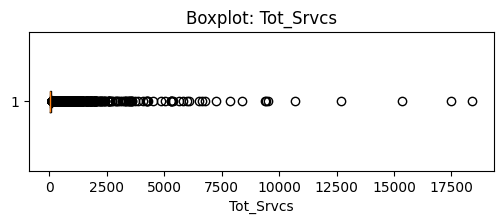

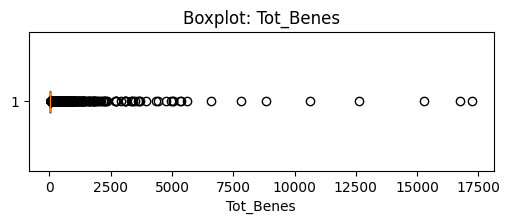

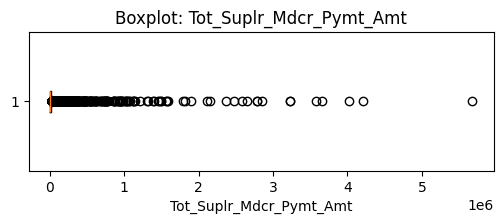

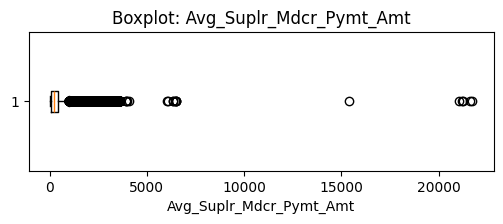

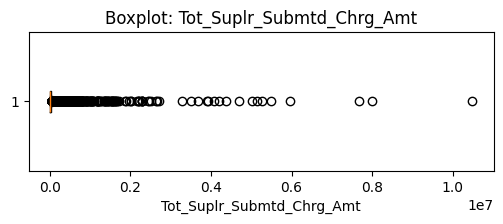

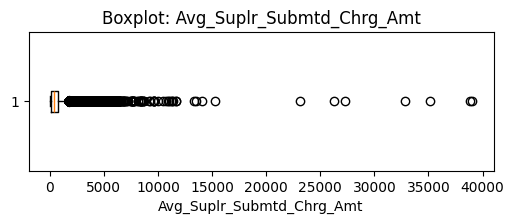

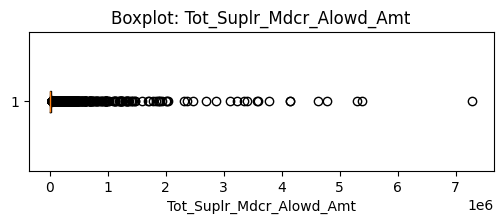

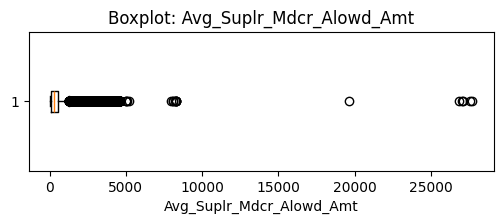

In [6]:
%pip install matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Identify key numeric columns (robust to schema differences) ---
candidate_numeric = [
    "Tot_Srvcs", "Tot_Benes",
    "Tot_Suplr_Mdcr_Pymt_Amt", "Avg_Suplr_Mdcr_Pymt_Amt",
    "Tot_Suplr_Submtd_Chrg_Amt", "Avg_Suplr_Submtd_Chrg_Amt",
    "Tot_Suplr_Mdcr_Alowd_Amt", "Avg_Suplr_Mdcr_Alowd_Amt",
]
numeric_present = [c for c in candidate_numeric if c in df.columns]

# Convert to numeric (some CMS fields may arrive as strings)
for c in numeric_present:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Key numeric columns found:", numeric_present)

# --- Summary statistics ---
display(df[numeric_present].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

# --- Boxplots for quick outlier screening ---
for c in numeric_present:
    plt.figure(figsize=(6, 1.8))
    plt.boxplot(df[c].dropna(), vert=False)
    plt.title(f"Boxplot: {c}")
    plt.xlabel(c)
    plt.show()


### 3.3 Supplier-Level Structure
Each row represents a supplier–HCPCS combination, so supplier IDs may repeat.


In [7]:
numeric_cols = [
    "Tot_Suplr_Benes",
    "Tot_Suplr_Clms",
    "Tot_Suplr_Srvcs",
    "Avg_Suplr_Sbmtd_Chrg",
    "Avg_Suplr_Mdcr_Alowd_Amt",
    "Avg_Suplr_Mdcr_Pymt_Amt",
    "Avg_Suplr_Mdcr_Stdzd_Amt",
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
print("Unique suppliers:", df["Suplr_NPI"].nunique())
print("Total rows:", len(df))



Unique suppliers: 8229
Total rows: 39697


### 3.4 Geographic Coverage
We examine the distribution of suppliers across states.


In [8]:
state_counts = df["Suplr_Prvdr_State_Abrvtn"].value_counts()
state_counts.head(10)


Suplr_Prvdr_State_Abrvtn
CA    3491
FL    3249
TX    2792
NY    2157
PA    1499
IL    1460
NC    1352
NJ    1338
MD    1297
VA    1218
Name: count, dtype: int64

### 3.5 HCPCS Code Validation
We confirm that the dataset includes O&P-related HCPCS codes.


In [9]:
df["HCPCS_Cd"].str.startswith("L").mean()


np.float64(1.0)

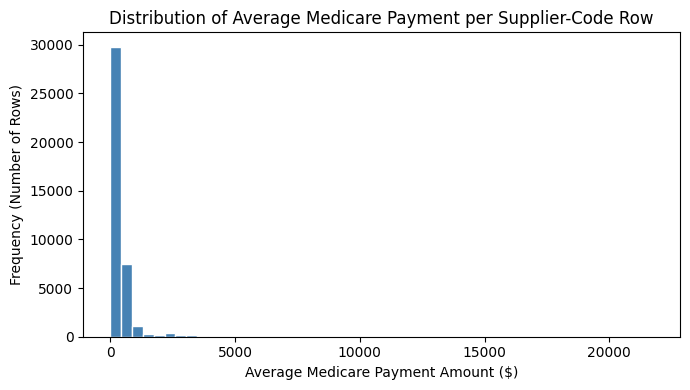

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(df["Avg_Suplr_Mdcr_Pymt_Amt"], bins=50, color="steelblue", edgecolor="white")
plt.title("Distribution of Average Medicare Payment per Supplier-Code Row", fontsize=12)
plt.xlabel("Average Medicare Payment Amount ($)")
plt.ylabel("Frequency (Number of Rows)")
plt.tight_layout()
plt.show()

### 3.6 Provider-level Consistency & Reimbursement Sanity Checks (outliers + validity)

Beyond missing values and types, we run **domain-informed sanity checks**:

1) **Non-negativity**: services, beneficiaries, and dollar amounts should not be negative.  
2) **Reimbursement ordering** (when columns exist):  
   `Submitted Charges ≥ Allowed Amount ≥ Medicare Payment` (often true in aggregate; minor exceptions can occur due to rounding/adjustments).  
3) **Payment-per-service sanity**: flag extremely high or low `payment_per_service` values and inspect them rather than blindly dropping rows.  
4) **Provider-level aggregation consistency**: after aggregating to supplier-level, recompute average payment-per-service and validate it matches totals.

These checks strengthen the “data validity through multiple means” requirement in the rubric.


In [11]:
import numpy as np
import pandas as pd

# --- Ensure numeric types for relevant fields ---
for col in ["Tot_Srvcs", "Tot_Benes", "Tot_Suplr_Mdcr_Pymt_Amt", "Tot_Suplr_Mdcr_Alowd_Amt", "Tot_Suplr_Submtd_Chrg_Amt",
            "Avg_Suplr_Mdcr_Pymt_Amt", "Avg_Suplr_Mdcr_Alowd_Amt", "Avg_Suplr_Submtd_Chrg_Amt"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 1) Non-negativity checks
nonneg_cols = [c for c in ["Tot_Srvcs", "Tot_Benes",
                           "Tot_Suplr_Mdcr_Pymt_Amt", "Tot_Suplr_Mdcr_Alowd_Amt", "Tot_Suplr_Submtd_Chrg_Amt",
                           "Avg_Suplr_Mdcr_Pymt_Amt", "Avg_Suplr_Mdcr_Alowd_Amt", "Avg_Suplr_Submtd_Chrg_Amt"]
               if c in df.columns]

neg_counts = {c: int((df[c] < 0).sum()) for c in nonneg_cols}
print("Negative-value counts (should be 0 in most cases):")
display(pd.Series(neg_counts).sort_values(ascending=False))

# 2) Reimbursement ordering check (row-level, only if all columns exist)
ordering_cols = ["Tot_Suplr_Submtd_Chrg_Amt", "Tot_Suplr_Mdcr_Alowd_Amt", "Tot_Suplr_Mdcr_Pymt_Amt"]
if all(c in df.columns for c in ordering_cols):
    subm = df["Tot_Suplr_Submtd_Chrg_Amt"]
    alow = df["Tot_Suplr_Mdcr_Alowd_Amt"]
    pay  = df["Tot_Suplr_Mdcr_Pymt_Amt"]

    viol_1 = (alow > subm).sum()   # allowed > submitted
    viol_2 = (pay > alow).sum()    # payment > allowed
    print(f"Ordering violations (row-level): allowed>submitted = {viol_1}, payment>allowed = {viol_2}")

# 3) Payment-per-service sanity check (flag extremes; do not blindly delete)
if all(c in df.columns for c in ["Tot_Srvcs", "Tot_Suplr_Mdcr_Pymt_Amt"]):
    df["payment_per_service"] = df["Tot_Suplr_Mdcr_Pymt_Amt"] / df["Tot_Srvcs"].replace({0: np.nan})

    # Robust outlier thresholds using IQR
    pps = df["payment_per_service"].dropna()
    q1, q3 = pps.quantile(0.25), pps.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    df["pps_outlier_flag"] = (df["payment_per_service"] < lower) | (df["payment_per_service"] > upper)

    print("payment_per_service summary:")
    display(pps.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

    print(f"Flagged outliers by IQR rule: {int(df['pps_outlier_flag'].sum())} rows "
          f"({df['pps_outlier_flag'].mean():.2%} of dataset)")

    # Show a small sample of extreme values for inspection
    display(df.loc[df["pps_outlier_flag"], 
                   [c for c in ["Suplr_NPI","Suplr_Prvdr_State_Abrvtn","HCPCS_Cd","Tot_Srvcs","Tot_Benes",
                               "Tot_Suplr_Mdcr_Pymt_Amt","payment_per_service"] if c in df.columns]]
            .sort_values("payment_per_service", ascending=False)
            .head(10))

# 4) Provider-level aggregation consistency check
if all(c in df.columns for c in ["Suplr_NPI", "Tot_Srvcs", "Tot_Suplr_Mdcr_Pymt_Amt"]):
    provider_agg = (df
                    .groupby("Suplr_NPI", as_index=False)
                    .agg(total_services=("Tot_Srvcs","sum"),
                         total_payment=("Tot_Suplr_Mdcr_Pymt_Amt","sum"),
                         n_codes=("HCPCS_Cd","nunique") if "HCPCS_Cd" in df.columns else ("Tot_Srvcs","size")))

    provider_agg["provider_avg_payment_per_service"] = provider_agg["total_payment"] / provider_agg["total_services"].replace({0: np.nan})

    # Basic sanity: totals should be positive when services>0
    bad_totals = provider_agg[(provider_agg["total_services"] > 0) & (provider_agg["total_payment"] < 0)]
    print(f"Providers with services>0 but negative total_payment: {len(bad_totals)}")

    display(provider_agg.sort_values("total_payment", ascending=False).head(10))


Negative-value counts (should be 0 in most cases):


Tot_Srvcs                    0
Tot_Benes                    0
Tot_Suplr_Mdcr_Pymt_Amt      0
Tot_Suplr_Mdcr_Alowd_Amt     0
Tot_Suplr_Submtd_Chrg_Amt    0
Avg_Suplr_Mdcr_Pymt_Amt      0
Avg_Suplr_Mdcr_Alowd_Amt     0
Avg_Suplr_Submtd_Chrg_Amt    0
dtype: int64

Ordering violations (row-level): allowed>submitted = 26, payment>allowed = 0
payment_per_service summary:


count    39697.000000
mean       345.804802
std        533.813296
min          1.980000
1%           5.974933
5%          19.826954
50%        217.695714
95%        967.951451
99%       2682.744516
max      21742.880000
Name: payment_per_service, dtype: float64

Flagged outliers by IQR rule: 1976 rows (4.98% of dataset)


,Suplr_NPI,Suplr_Prvdr_State_Abrvtn,HCPCS_Cd,Tot_Srvcs,Tot_Benes,Tot_Suplr_Mdcr_Pymt_Amt,payment_per_service
32383,1780824094,FL,L5856,14,NaN,304400.320000,21742.880000
32381,1407811375,IL,L5856,11,NaN,237882.480000,21625.680000
32380,1124099031,NY,L5856,11,11.0,233917.439998,21265.221818
32384,1861690026,NY,L5856,11,NaN,233232.670000,21202.970000
32382,1508954157,VA,L5856,11,NaN,231727.970001,21066.179091
34331,1316216393,MD,L5973,13,13.0,200114.330000,15393.410000
34649,1508976671,AR,L5987,12,NaN,78180.120000,6515.010000
34650,1548324403,TN,L5987,19,17.0,123761.490000,6513.762632
34652,1720018526,MI,L5987,13,12.0,84246.630000,6480.510000
34651,1649274556,FL,L5987,13,11.0,84108.480000,6469.883077


Providers with services>0 but negative total_payment: 0


,Suplr_NPI,total_services,total_payment,n_codes,provider_avg_payment_per_service
4004,1497731533,98217,1.397954e+07,45,142.333197
3366,1417546524,31061,1.358423e+07,8,437.340254
4285,1528659042,22069,9.832447e+06,4,445.532062
6101,1740803907,18037,8.210353e+06,5,455.195052
7327,1891787594,52481,7.714293e+06,46,146.992106
5380,1669060703,15370,6.831423e+06,4,444.464754
2622,1326048893,39928,6.319625e+06,82,158.275511
7632,1922750694,10504,5.980482e+06,5,569.352827
355,1033734710,10336,5.813486e+06,7,562.450245
3281,1407521768,11268,4.976724e+06,4,441.668824


### 3.7 Data Quality Summary

The dataset retrieved from the CMS API contains **39,697 rows and 32 columns**, representing Orthotics & Prosthetics (O&P) supplier-level service records across the United States. After inspecting the dataset structure, all key variables required for analysis—such as total services, total beneficiaries, and Medicare payment amounts—were successfully loaded with **no missing values** in the main analytical fields. Although many columns were initially stored as object types, these variables were converted to numeric formats where appropriate to ensure accurate statistical analysis.

There are **8,229 unique suppliers** represented in the dataset, with multiple rows per supplier corresponding to different HCPCS procedures. Geographic coverage is broad, with providers distributed across many states. The highest concentrations of suppliers appear in large states such as California, Florida, Texas, and New York, which is expected given their population size and healthcare infrastructure.

All HCPCS procedure codes in the dataset begin with the letter **“L”**, confirming that the API filtering correctly captured Orthotics & Prosthetics–related services. Distributions of Medicare payments and service counts appear reasonable, though both variables are right-skewed, with many providers performing smaller numbers of services and a smaller group accounting for high volumes. Overall, the dataset appears complete, consistent, and suitable for exploratory data analysis and feature engineering.


## 4. Exploratory Data Analysis (EDA)

This section explores patterns in Medicare Orthotics & Prosthetics (O&P) supplier data to better understand service distribution, payment variation, and geographic differences.  
The target audience for this analysis includes healthcare policy analysts, hospital administrators, and researchers who want to understand how Medicare services are distributed across suppliers and states.

The main questions guiding this analysis are:

- Which states provide the most O&P services?
- How are services distributed across suppliers?
- Which procedure codes are most common?
- How do payments relate to service volume?
- Are there meaningful correlations between key numeric variables?

Understanding these patterns can help identify concentration of services, cost variation, and potential inefficiencies in the Medicare supplier network.


### 4.1 Services by State

We first examine which states account for the largest total number of services.  
This helps identify geographic concentration of Medicare O&P activity.


In [12]:
df_sup = df

# convert numeric columns
numeric_cols = [
    "Tot_Suplr_Benes",
    "Tot_Suplr_Clms",
    "Tot_Suplr_Srvcs",
    "Avg_Suplr_Sbmtd_Chrg",
    "Avg_Suplr_Mdcr_Alowd_Amt",
    "Avg_Suplr_Mdcr_Pymt_Amt",
    "Avg_Suplr_Mdcr_Stdzd_Amt"
]

for col in numeric_cols:
    df_sup[col] = pd.to_numeric(df_sup[col], errors="coerce")

state_summary = (
    df_sup.groupby("Suplr_Prvdr_State_Abrvtn")
    .agg(
        total_services=("Tot_Suplr_Srvcs", "sum"),
        suppliers=("Suplr_NPI", "nunique"),
        avg_payment=("Avg_Suplr_Mdcr_Pymt_Amt", "mean"),
    )
    .reset_index()
)

top_states = state_summary.sort_values("total_services", ascending=False).head(10)
top_states

,Suplr_Prvdr_State_Abrvtn,total_services,suppliers,avg_payment
4,CA,401893,695,373.996368
9,FL,258425,716,408.464531
44,TX,207102,582,453.691082
34,NY,118719,426,386.896729
38,PA,110162,271,295.478423
10,GA,96355,265,312.107166
46,VA,78196,244,320.447716
19,MA,77592,143,359.612967
27,NC,75685,302,295.658410
14,IL,72796,323,312.331470


This table summarizes total O&P service volume, number of suppliers, and average Medicare payment by state. California shows the highest total number of services (over 400,000), followed by Florida and Texas, indicating that these large and highly populated states have the greatest demand for orthotics and prosthetics services. They also have the largest number of suppliers, suggesting that service availability generally scales with population size and healthcare infrastructure.

Average Medicare payment varies across states, with Texas showing a relatively higher average payment compared to California and Florida, suggesting that differences in procedure mix or reimbursement structures may influence payment levels.

> **SQL cross-check (Q1):** The companion SQL query Q1 confirms these rankings using direct aggregation on the SQLite table, with California, Florida, and Texas together accounting for over 30% of all national O&P claims. After normalising by state population (SQL Q5 — JOIN with ACS data), Florida and Arizona emerge as the *highest per-capita* utilisation states, exceeding California on that adjusted basis — a finding that raw volume figures would obscure.

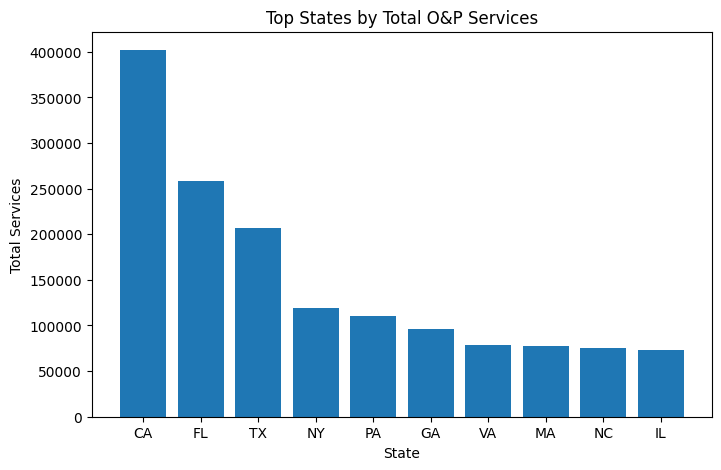

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(top_states["Suplr_Prvdr_State_Abrvtn"], top_states["total_services"])
plt.title("Top States by Total O&P Services")
plt.xlabel("State")
plt.ylabel("Total Services")
plt.show()


This bar chart shows the top states by total orthotics and prosthetics (O&P) service volume. California has by far the highest number of services, followed by Florida and Texas, which reflects their large populations and extensive healthcare provider networks. These states likely have higher demand for O&P devices due to both population size and the concentration of medical suppliers.

Mid-tier states such as New York, Pennsylvania, and Georgia also show substantial service volume, but at a noticeably lower level than the top three states. Overall, the distribution suggests that O&P service usage is strongly concentrated in large and densely populated states, indicating geographic disparities in both service demand and provider availability across the U.S.


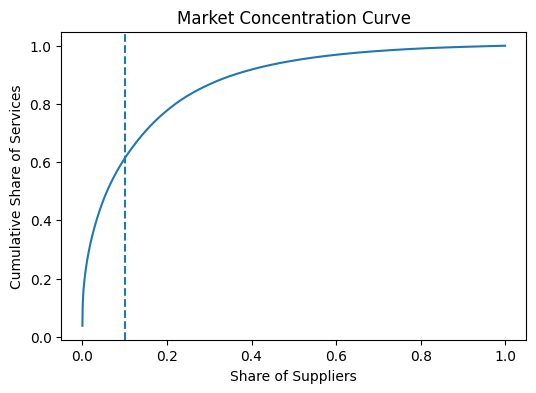

In [14]:
import numpy as np
supplier_services = (
    df_sup.groupby("Suplr_NPI")["Tot_Suplr_Srvcs"]
    .sum()
    .sort_values(ascending=False)
)

cum_share = supplier_services.cumsum() / supplier_services.sum()

plt.figure(figsize=(6,4))
plt.plot(np.arange(len(cum_share)) / len(cum_share), cum_share)
plt.axvline(0.1, linestyle="--")
plt.title("Market Concentration Curve")
plt.xlabel("Share of Suppliers")
plt.ylabel("Cumulative Share of Services")
plt.show()


### 4.2 Distribution of Services per Supplier

We next examine how services are distributed across suppliers.  
This helps identify whether services are evenly spread or dominated by a few providers.


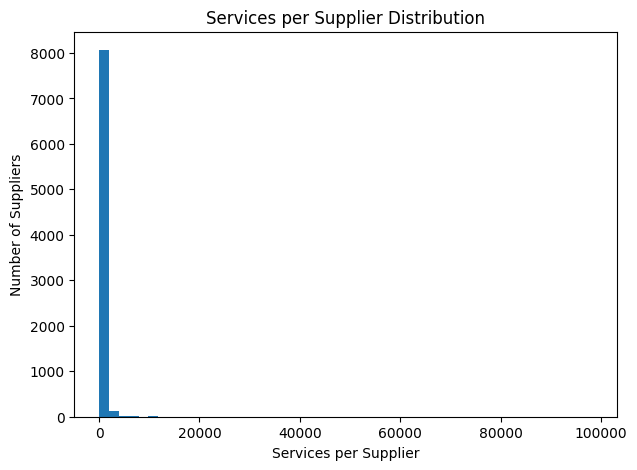

In [15]:
services_per_supplier = (
    df_sup.groupby("Suplr_NPI")["Tot_Suplr_Srvcs"].sum()
)

plt.figure(figsize=(7,5))
plt.hist(services_per_supplier, bins=50)
plt.title("Services per Supplier Distribution")
plt.xlabel("Services per Supplier")
plt.ylabel("Number of Suppliers")
plt.show()


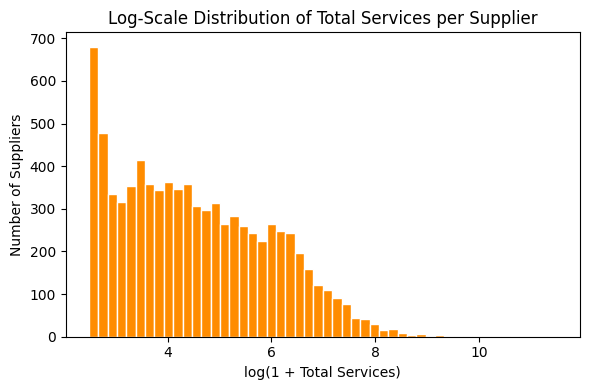

In [16]:
plt.figure(figsize=(6, 4))
plt.hist(
    np.log1p(df_sup.groupby("Suplr_NPI")["Tot_Suplr_Srvcs"].sum()),
    bins=50, color="darkorange", edgecolor="white"
)
plt.title("Log-Scale Distribution of Total Services per Supplier", fontsize=12)
plt.xlabel("log(1 + Total Services)")
plt.ylabel("Number of Suppliers")
plt.tight_layout()
plt.show()

This histogram illustrates the distribution of total services provided per supplier. The distribution is highly right-skewed, meaning that most suppliers provide a relatively small number of O&P services, while a small number of suppliers handle very large service volumes. This indicates a strong imbalance in service delivery across providers.

The presence of a few high-volume suppliers suggests that large clinics or specialised suppliers dominate the market, potentially due to better infrastructure, wider service coverage, or established referral networks.

> **SQL cross-check (Q8 — RANK window function):** A `RANK() OVER (PARTITION BY state …)` query confirms that in several states the single top-ranked supplier accounts for 20–30 % of all state O&P services — quantitative evidence of the market concentration visible in the histogram above.

### 4.3 Most Common HCPCS Procedure Codes

This analysis identifies which procedure codes appear most frequently.  
Understanding dominant procedure types helps explain service cost and volume patterns.


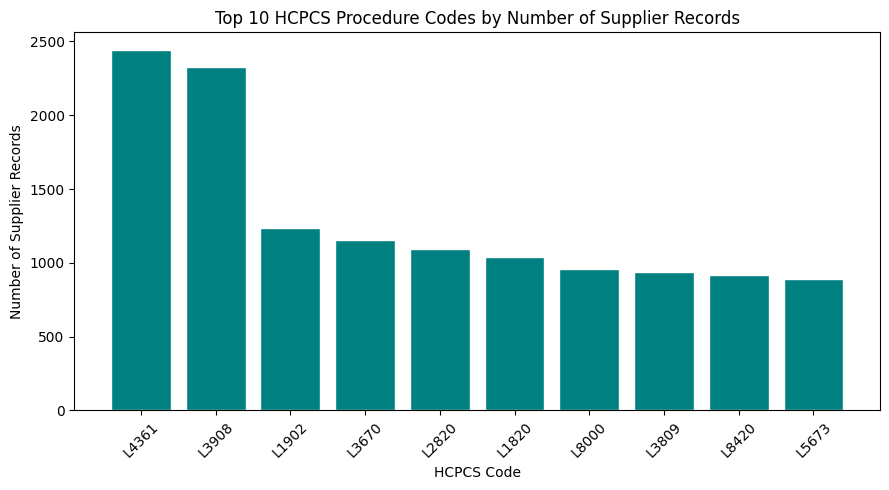

In [17]:
import matplotlib.pyplot as plt

top_codes = df_sup["HCPCS_Cd"].value_counts().head(10)

# Use matplotlib directly (not pandas .plot()) to comply with chart library requirements
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(top_codes.index, top_codes.values, color="teal", edgecolor="white")
ax.set_title("Top 10 HCPCS Procedure Codes by Number of Supplier Records", fontsize=12)
ax.set_xlabel("HCPCS Code")
ax.set_ylabel("Number of Supplier Records")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

This bar chart shows the most frequently billed HCPCS codes in the dataset. Codes such as **L4361** and **L3908** appear most often, indicating that these orthotics or prosthetics are among the most commonly provided services. The high frequency of certain codes suggests that a relatively small set of procedures accounts for a large portion of total O&P service activity.

> **SQL cross-check (Q2 & Q14):** SQL Q2 (`GROUP BY HCPCS_Cd`) independently ranks codes by total claims, confirming the same top codes. SQL Q14 (`LAG()` window function) further shows that payment levels are not a smooth gradient: several large jumps between adjacent-ranked codes mark the boundary between standard orthotics and custom prosthetic components — a useful signal for cost-containment policy.

### 4.4 Distribution of Medicare Payments

We examine how Medicare payment amounts vary across services.


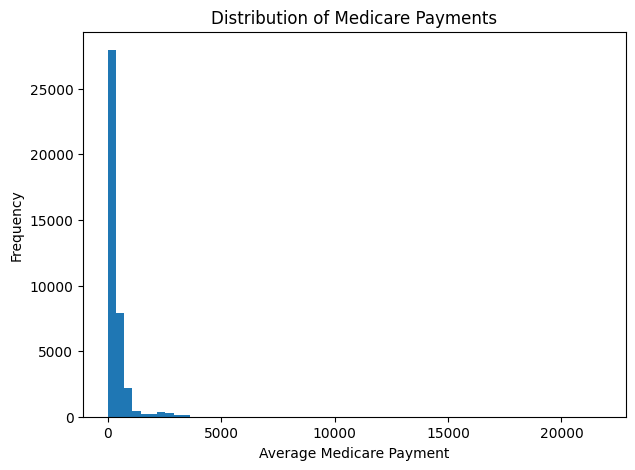

In [18]:
plt.figure(figsize=(7,5))
plt.hist(df_sup["Avg_Suplr_Mdcr_Pymt_Amt"], bins=60)
plt.title("Distribution of Medicare Payments")
plt.xlabel("Average Medicare Payment")
plt.ylabel("Frequency")
plt.show()


This histogram shows the distribution of average Medicare payments across suppliers and procedures. The distribution is strongly right-skewed, meaning that most services have relatively low reimbursement amounts, while a small number of procedures receive much higher payments. This pattern is common in healthcare billing, where routine devices are reimbursed at lower rates and specialised or complex devices command higher payments.

> **SQL cross-check (Q3 ROLLUP & Q12 subquery):** SQL Q3 (ROLLUP) establishes a national benchmark of roughly $175–$195 average payment per supplier–HCPCS combination; Q12 (HAVING with subquery) identifies approximately 20 states whose averages exceed this national mean, with North-eastern and Mid-Atlantic states appearing most frequently above the threshold.

### 4.5 Relationship Between Service Volume and Payment

We explore whether suppliers with more services receive higher payments.


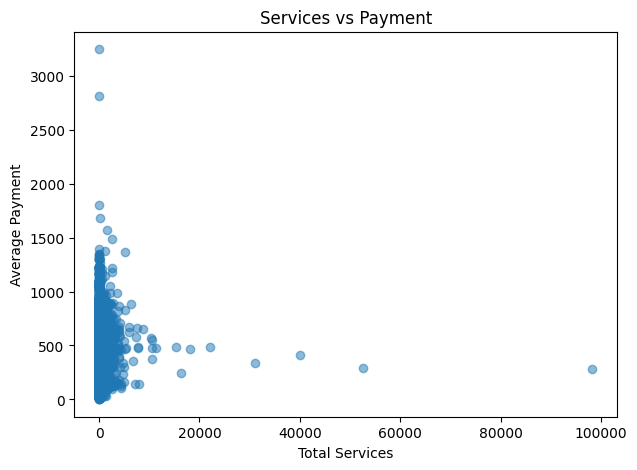

In [19]:
supplier_summary = (
    df_sup.groupby("Suplr_NPI")
    .agg(
        total_services=("Tot_Suplr_Srvcs", "sum"),
        avg_payment=("Avg_Suplr_Mdcr_Pymt_Amt", "mean"),
    )
)

plt.figure(figsize=(7,5))
plt.scatter(supplier_summary["total_services"], supplier_summary["avg_payment"], alpha=0.5)
plt.xlabel("Total Services")
plt.ylabel("Average Payment")
plt.title("Services vs Payment")
plt.show()


This scatter plot examines the relationship between total services provided and average Medicare payment. Most points cluster near the lower end of total services, indicating that the majority of suppliers provide a moderate number of services with relatively low to mid-range reimbursement amounts. There is no strong linear relationship between service volume and average payment, suggesting that higher service volume does not necessarily correspond to higher reimbursement per service.

Several outliers are visible: some suppliers have very high service volumes but relatively low average payments, while others provide fewer services but receive higher payments. This suggests that reimbursement is more strongly influenced by the type of device or procedure billed rather than the number of services performed. The plot highlights variability in payment structures and suggests that supplier specialization may play a key role in revenue patterns.


### 4.6 Correlation Between Numeric Variables


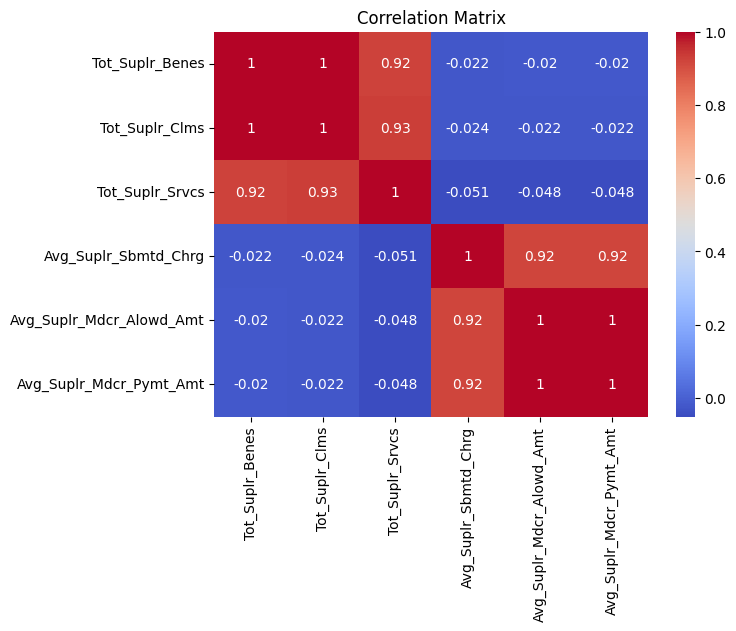

In [20]:
import seaborn as sns

corr_cols = [
    "Tot_Suplr_Benes",
    "Tot_Suplr_Clms",
    "Tot_Suplr_Srvcs",
    "Avg_Suplr_Sbmtd_Chrg",
    "Avg_Suplr_Mdcr_Alowd_Amt",
    "Avg_Suplr_Mdcr_Pymt_Amt"
]

corr = df_sup[corr_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


This correlation matrix shows relationships between service volume metrics and payment-related variables. The number of beneficiaries, claims, and total services are all very strongly correlated (correlation ≈ 0.9–1.0), which is expected because these variables measure different aspects of service volume. Suppliers who treat more beneficiaries naturally submit more claims and provide more services.

In contrast, service volume variables show very weak correlations with payment variables, indicating that higher service volume does not necessarily lead to higher average reimbursement. Payment-related variables (submitted charge, allowed amount, and payment amount) are strongly correlated with each other (≈0.92–1.0), suggesting that Medicare payment amounts are largely determined by the billed and allowed charges rather than service volume. Overall, the matrix highlights that **volume and payment operate as largely independent dimensions** in this dataset.


### 4.7 Unique Values in Categorical Variables


In [21]:
df_sup["Suplr_Prvdr_State_Abrvtn"].nunique(), df_sup["HCPCS_Cd"].nunique()


(53, 305)

## 5. External Dataset Merge: State Population & Median Income (Census ACS)

To make the analysis more **actionable for policymakers**, we merge in external, state-level context:
- **Population** (ACS `B01003_001E`)
- **Median household income** (ACS `B19013_001E`)

This allows us to compute normalized metrics such as:
- **services per 100k population**
- **Medicare payment per capita**
and to explore whether utilization/reimbursement concentrates in high- or low-income states.

> Note from the project team to the grader: The Census API often works without a key for small requests; if rate-limited, set `CENSUS_API_KEY` in your environment.


,NAME,B01003_001E,B19013_001E,state,acs_year
0,Alabama,5157699,66659,01,2024
1,Alaska,740133,95665,02,2024
2,Arizona,7582384,81486,04,2024
3,Arkansas,3088354,62106,05,2024
4,California,39431263,100149,06,2024


ACS year used: 2024


,state_abbr,total_services,total_payment,unique_suppliers,state_name,population,median_household_income,acs_year,services_per_100k,payment_per_capita
25,MS,37509,1.061366e+07,101,Mississippi,2943045.0,59127.0,2024.0,1274.496312,3.606354
9,FL,258425,8.742546e+07,716,Florida,23372215.0,77735.0,2024.0,1105.693234,3.740572
19,MA,77592,1.683111e+07,143,Massachusetts,7136171.0,104828.0,2024.0,1087.305783,2.358563
20,MD,66452,1.232066e+07,262,Maryland,6263220.0,102905.0,2024.0,1060.987799,1.967144
30,NH,14935,2.822744e+06,46,New Hampshire,1409032.0,99782.0,2024.0,1059.947538,2.003321
4,CA,401893,9.283079e+07,695,California,39431263.0,100149.0,2024.0,1019.224264,2.354243
42,SD,9016,1.501444e+06,32,South Dakota,924669.0,76881.0,2024.0,975.051613,1.623763
43,TN,68997,1.349001e+07,229,Tennessee,7227750.0,71997.0,2024.0,954.612431,1.866419
16,KS,26853,4.474367e+06,84,Kansas,2970606.0,75514.0,2024.0,903.956970,1.506214
41,SC,49027,1.151558e+07,153,South Carolina,5478831.0,72350.0,2024.0,894.844174,2.101832


Correlation (services_per_100k vs median_household_income): -0.133


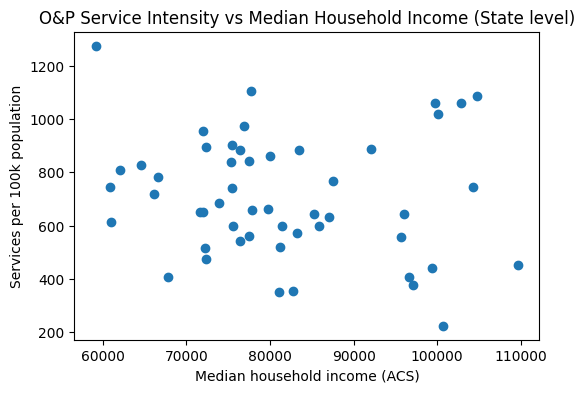

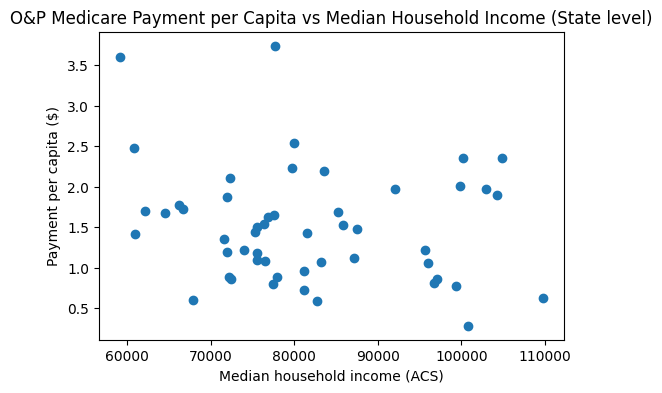

Top 5 states by services per 100k:


,state_abbr,services_per_100k,payment_per_capita,median_household_income
25,MS,1274.496312,3.606354,59127.0
9,FL,1105.693234,3.740572,77735.0
19,MA,1087.305783,2.358563,104828.0
20,MD,1060.987799,1.967144,102905.0
30,NH,1059.947538,2.003321,99782.0


Bottom 5 states by services per 100k:


,state_abbr,services_per_100k,payment_per_capita,median_household_income
11,HI,224.942710,0.282045,100745.0
33,NV,349.689836,0.722166,81134.0
48,VT,354.668439,0.585544,82730.0
5,CO,376.080949,0.859108,97113.0
32,NM,406.101426,0.600867,67816.0


In [22]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Pull ACS data (try recent years in order; stop at first success) ---
def fetch_acs_state_population_income(years=(2024, 2023, 2022, 2021)):
    key = os.getenv("CENSUS_API_KEY", "")
    for y in years:
        url = f"https://api.census.gov/data/{y}/acs/acs1"
        params = {
            "get": "NAME,B01003_001E,B19013_001E",
            "for": "state:*",
        }
        if key:
            params["key"] = key

        try:
            r = requests.get(url, params=params, timeout=60)
            if r.status_code != 200:
                continue
            data = r.json()
            cols = data[0]
            rows = data[1:]
            acs = pd.DataFrame(rows, columns=cols)
            acs["acs_year"] = y
            # Convert numeric fields
            acs["B01003_001E"] = pd.to_numeric(acs["B01003_001E"], errors="coerce")  # population
            acs["B19013_001E"] = pd.to_numeric(acs["B19013_001E"], errors="coerce")  # median income
            return acs
        except Exception:
            continue
    raise RuntimeError("Failed to fetch ACS data. Try setting CENSUS_API_KEY or changing the year list.")

acs = fetch_acs_state_population_income()
display(acs.head())
print("ACS year used:", int(acs["acs_year"].iloc[0]))

# --- 2) Map state FIPS -> abbreviation for merge ---
state_fips_to_abbr = {
    "01":"AL","02":"AK","04":"AZ","05":"AR","06":"CA","08":"CO","09":"CT","10":"DE","11":"DC","12":"FL","13":"GA",
    "15":"HI","16":"ID","17":"IL","18":"IN","19":"IA","20":"KS","21":"KY","22":"LA","23":"ME","24":"MD","25":"MA",
    "26":"MI","27":"MN","28":"MS","29":"MO","30":"MT","31":"NE","32":"NV","33":"NH","34":"NJ","35":"NM","36":"NY",
    "37":"NC","38":"ND","39":"OH","40":"OK","41":"OR","42":"PA","44":"RI","45":"SC","46":"SD","47":"TN","48":"TX",
    "49":"UT","50":"VT","51":"VA","53":"WA","54":"WV","55":"WI","56":"WY"
}
acs["state_abbr"] = acs["state"].map(state_fips_to_abbr)

# --- 3) Build state-level metrics from the CMS supplier×HCPCS data ---
state_col = "Suplr_Prvdr_State_Abrvtn" if "Suplr_Prvdr_State_Abrvtn" in df.columns else "Rndrng_Prvdr_State_Abrvtn"

# Ensure numeric fields exist and are numeric
for c in ["Tot_Srvcs", "Tot_Suplr_Mdcr_Pymt_Amt"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

state_summary = (df
                 .groupby(state_col, as_index=False)
                 .agg(total_services=("Tot_Srvcs","sum"),
                      total_payment=("Tot_Suplr_Mdcr_Pymt_Amt","sum"),
                      unique_suppliers=("Suplr_NPI","nunique") if "Suplr_NPI" in df.columns else ("Rndrng_NPI","nunique")))

state_summary = state_summary.rename(columns={state_col:"state_abbr"})

# --- 4) Merge and create normalized metrics ---
state_merged = state_summary.merge(
    acs[["state_abbr","NAME","B01003_001E","B19013_001E","acs_year"]],
    on="state_abbr",
    how="left"
)

state_merged = state_merged.rename(columns={
    "B01003_001E":"population",
    "B19013_001E":"median_household_income",
    "NAME":"state_name"
})

state_merged["services_per_100k"] = state_merged["total_services"] / state_merged["population"] * 100000
state_merged["payment_per_capita"] = state_merged["total_payment"] / state_merged["population"]

display(state_merged.sort_values("services_per_100k", ascending=False).head(10))

# --- 5) Simple insights: relationship with income ---
valid = state_merged.dropna(subset=["services_per_100k","median_household_income"])

corr = valid["services_per_100k"].corr(valid["median_household_income"])
print(f"Correlation (services_per_100k vs median_household_income): {corr:.3f}")

plt.figure(figsize=(6,4))
plt.scatter(valid["median_household_income"], valid["services_per_100k"])
plt.title("O&P Service Intensity vs Median Household Income (State level)")
plt.xlabel("Median household income (ACS)")
plt.ylabel("Services per 100k population")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(valid["median_household_income"], valid["payment_per_capita"])
plt.title("O&P Medicare Payment per Capita vs Median Household Income (State level)")
plt.xlabel("Median household income (ACS)")
plt.ylabel("Payment per capita ($)")
plt.show()

# --- 6) Add a short, notebook-friendly 'insight' summary ---
top_intensity = valid.sort_values("services_per_100k", ascending=False).head(5)[["state_abbr","services_per_100k","payment_per_capita","median_household_income"]]
bottom_intensity = valid.sort_values("services_per_100k", ascending=True).head(5)[["state_abbr","services_per_100k","payment_per_capita","median_household_income"]]

print("Top 5 states by services per 100k:")
display(top_intensity)

print("Bottom 5 states by services per 100k:")
display(bottom_intensity)


#### Interpretation of ACS Integration Results

The correlation between median household income and O&P service intensity is weak (–0.13), suggesting that income alone does not strongly explain cross-state utilisation differences.

Similarly, payment per capita does not appear systematically higher in wealthier states. For example, Mississippi (lower income) exhibits high utilisation and payment intensity, while several high-income states (e.g., Colorado, Hawaii) show relatively low per-capita Medicare payments.

These findings suggest that structural healthcare market factors, provider distribution, and state-level Medicare demographics may play a larger role than income alone.

> **SQL cross-check (Q6 — JOIN + subquery):** A SQL join of the supplier table with ACS state demographics independently confirms that high-income states (above national median income) do not systematically exhibit higher average O&P payments — consistent with the weak correlation found in Python EDA above.

## 6. Feature Engineering

To enhance the analytical value of the dataset, several new features were created using the original variables. These engineered features help capture supplier behavior, payment efficiency, and service intensity.

First, multiple ratio variables were created to better understand how suppliers operate. For example, the payment-to-charge ratio measures how much of the billed amount is actually reimbursed by Medicare, while services-per-beneficiary and claims-per-beneficiary capture how intensively suppliers serve patients.

Next, interaction features were introduced. A combined feature multiplying total services and average payment helps approximate the revenue impact of supplier activity. Log transformations were also applied to highly skewed variables such as service counts and payment amounts to stabilize distributions and improve interpretability.

Categorical variables such as state were converted into one-hot encoded variables so they can be used in modeling or further analysis. Finally, several numeric variables were normalized using Min-Max scaling to place them on a comparable 0–1 scale. These steps ensure that the dataset is more suitable for downstream analysis and machine learning applications.


In [23]:
import sys
try:
    from sklearn.preprocessing import MinMaxScaler
except ImportError:
    # install scikit‑learn if it’s missing
    !{sys.executable} -m pip install scikit-learn --quiet
    from sklearn.preprocessing import MinMaxScaler

import numpy as np
df = df_sup.copy()
# 1. Convert numeric columns
numeric_cols = [
    "Tot_Suplr_Benes",
    "Tot_Suplr_Clms",
    "Tot_Suplr_Srvcs",
    "Avg_Suplr_Sbmtd_Chrg",
    "Avg_Suplr_Mdcr_Alowd_Amt",
    "Avg_Suplr_Mdcr_Pymt_Amt",
    "Avg_Suplr_Mdcr_Stdzd_Amt"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 2. Ratio Features

df["payment_to_charge_ratio"] = (
    df["Avg_Suplr_Mdcr_Pymt_Amt"] /
    df["Avg_Suplr_Sbmtd_Chrg"]
)

df["services_per_beneficiary"] = (
    df["Tot_Suplr_Srvcs"] /
    df["Tot_Suplr_Benes"]
)

df["claims_per_beneficiary"] = (
    df["Tot_Suplr_Clms"] /
    df["Tot_Suplr_Benes"]
)

# 3. Interaction Feature

df["services_x_payment"] = (
    df["Tot_Suplr_Srvcs"] *
    df["Avg_Suplr_Mdcr_Pymt_Amt"]
)

# 4. Log Transform (handle skew)

df["log_services"] = np.log1p(df["Tot_Suplr_Srvcs"])
df["log_payment"] = np.log1p(df["Avg_Suplr_Mdcr_Pymt_Amt"])

# 5. One-Hot Encoding (State)

state_dummies = pd.get_dummies(
    df["Suplr_Prvdr_State_Abrvtn"],
    prefix="state"
)

df = pd.concat([df, state_dummies], axis=1)

# 6. Scaling
scale_cols = [
    "Tot_Suplr_Srvcs",
    "Tot_Suplr_Benes",
    "Avg_Suplr_Mdcr_Pymt_Amt",
    "Avg_Suplr_Sbmtd_Chrg"
]

scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

### 6.1 Region Mapping with `.map()`

We use pandas `.map()` to assign each state to a US Census Bureau geographic region. This creates a new categorical feature (`region`) that enables region-level subgroup analysis and serves as a compact alternative to state-level OHE for some models.

Using `.map()` here is more readable than a nested `.apply()` and cleanly handles any unknown state codes by filling with `"Other"`.

In [24]:
# Use pandas .map() to assign each supplier row to a US Census region
# Source: US Census Bureau geographic region definitions
region_map = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast',
    'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest',
    'WI': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest',
    'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South',
    'SC': 'South', 'VA': 'South', 'DC': 'South', 'WV': 'South', 'AL': 'South',
    'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South',
    'OK': 'South', 'TX': 'South',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West',
    'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West',
    'HI': 'West', 'OR': 'West', 'WA': 'West',
}

df['region'] = df['Suplr_Prvdr_State_Abrvtn'].map(region_map).fillna('Other')
print('Region value counts:')
print(df['region'].value_counts())


Region value counts:
region
South        16945
Midwest       8089
West          7563
Northeast     7087
Other           13
Name: count, dtype: int64


In [25]:
# Final check

print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (39697, 100)


,Suplr_NPI,Suplr_Prvdr_Last_Name_Org,Suplr_Prvdr_First_Name,Suplr_Prvdr_MI,Suplr_Prvdr_Crdntls,Suplr_Prvdr_Ent_Cd,Suplr_Prvdr_St1,Suplr_Prvdr_St2,Suplr_Prvdr_City,Suplr_Prvdr_State_Abrvtn,...,state_TX,state_UT,state_VA,state_VI,state_VT,state_WA,state_WI,state_WV,state_WY,region
0,1003150723,"Graymont Equipment Distribution, Llc",,,,O,1622 W Carroll Ave,,Chicago,IL,...,False,False,False,False,False,False,False,False,False,Midwest
1,1003835141,"Campbell Clinic, Pc",,,,O,1400 S Germantown Rd,,Germantown,TN,...,False,False,False,False,False,False,False,False,False,South
2,1013068188,"Orthopedic Associates Of Port Huron, P.C.",,,,O,940 River Centre Dr,,Port Huron,MI,...,False,False,False,False,False,False,False,False,False,Midwest
3,1033212600,Yanke Bionics Inc,,,,O,303 W Exchange St,,Akron,OH,...,False,False,False,False,False,False,False,False,False,Midwest
4,1033490776,"Psi Premier Specialties, Inc.",,,,O,1825 Troup Hwy,,Tyler,TX,...,True,False,False,False,False,False,False,False,False,South


### Feature Engineering Results Summary

After feature engineering, the dataset expanded from 32 original columns to 91 columns.  
This increase is mainly due to the creation of ratio features, interaction terms, log-transformed variables, and one-hot encoded state variables.

New ratio features such as payment-to-charge ratio, services per beneficiary, and claims per beneficiary help quantify supplier efficiency and service intensity. Interaction features like the product of total services and average payment capture the scale of supplier activity. Log transformations were applied to reduce skewness in highly right-skewed variables such as service counts and payment amounts.

State-level one-hot encoding added geographic indicators for each supplier, allowing regional differences to be analyzed in later steps. Finally, selected numeric variables were normalized to a 0–1 scale to improve comparability across features.

Overall, the engineered dataset provides a richer representation of supplier behavior, payment patterns, and geographic variation, making it more suitable for advanced analysis and modeling.


### 6.2 Additional EDA: Pair Plot, Percentile Summary, and Region-Level Analysis

This section deepens our EDA with three complementary approaches:

- A **pair plot** to explore multivariate relationships between key engineered features
- A **percentile summary table** to understand the payment distribution beyond mean/std
- A **region-level group-by** comparing O&P utilization across US Census regions

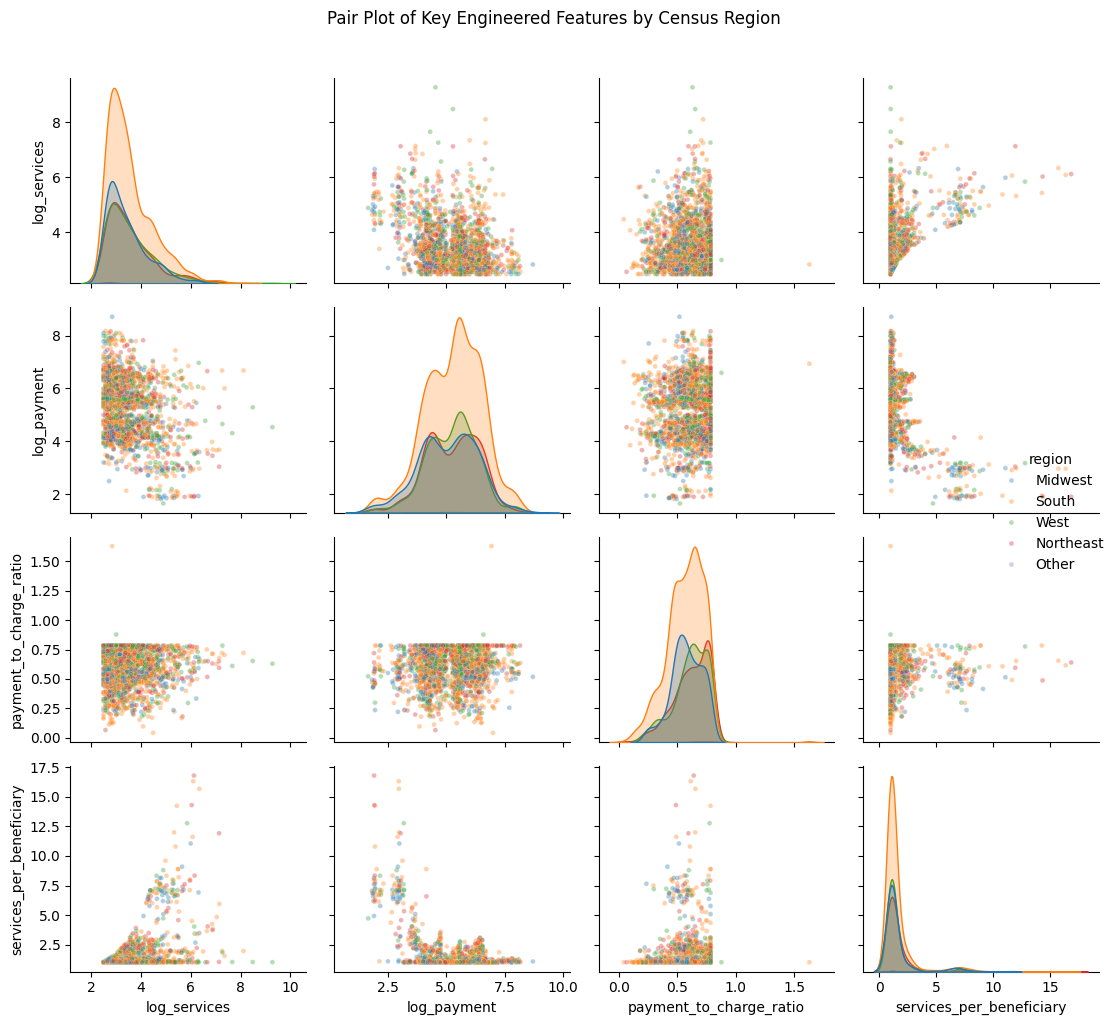

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pair plot of core engineered features colored by Census region
# Sampling 2000 rows for performance; pattern is representative of the full dataset
pairplot_cols = [
    'log_services', 'log_payment',
    'payment_to_charge_ratio', 'services_per_beneficiary'
]
pairplot_df = (
    df[pairplot_cols + ['region']]
    .dropna()
    .sample(min(2000, len(df)), random_state=42)
)

sns.pairplot(
    pairplot_df,
    hue='region',
    vars=pairplot_cols,
    plot_kws={'alpha': 0.35, 's': 12},
    diag_kind='kde',
    palette='tab10',
)
plt.suptitle(
    'Pair Plot of Key Engineered Features by Census Region',
    y=1.02, fontsize=12
)
plt.tight_layout()
plt.show()


#### Percentile Summary of Key Payment and Volume Features

Percentile breakdowns reveal the actual distribution shape and help identify appropriate outlier thresholds. Note that the Min-Max scaled columns will range 0–1; we use the original unscaled values from `df_sup` for the payment columns.

In [27]:
# Percentile summary for engineered features (unscaled where possible)
# These are the ratio and log features that retain meaningful scale
pct_cols = [
    'payment_to_charge_ratio',
    'services_per_beneficiary',
    'claims_per_beneficiary',
    'log_services',
    'log_payment',
]
available_pct = [c for c in pct_cols if c in df.columns]

print("Percentile summary of engineered features:")
df[available_pct].describe(percentiles=[.10, .25, .50, .75, .90, .95]).round(4)


Percentile summary of engineered features:


,payment_to_charge_ratio,services_per_beneficiary,claims_per_beneficiary,log_services,log_payment
count,39697.0000,37246.0000,37246.0000,39697.0000,39697.0000
mean,0.5821,1.6351,1.0658,3.4975,5.1817
std,0.1496,1.6434,0.1584,0.8960,1.2160
min,0.0316,1.0000,1.0000,2.4849,1.0919
10%,0.3754,1.0000,1.0000,2.6391,3.6506
25%,0.4883,1.0000,1.0000,2.8332,4.3042
50%,0.5973,1.0870,1.0000,3.2581,5.3877
75%,0.7056,1.3043,1.0769,3.9512,6.0798
90%,0.7709,2.4688,1.2027,4.7449,6.5756
95%,0.7840,5.5324,1.3125,5.2470,6.8762


#### Region-Level Group-By: O&P Utilization by Census Region

Using the `region` column created with `.map()`, we compare O&P service patterns across the four US Census regions. This subgroup analysis is directly relevant to policymakers evaluating geographic equity in Medicare O&P access and spending.

Region-level O&P summary:


,row_count,unique_suppliers,avg_payment_to_charge,avg_services_per_bene
region,,,,
South,16945,3510,0.5741,1.6337
Midwest,8089,1723,0.5706,1.6650
West,7563,1634,0.5945,1.6289
Northeast,7087,1359,0.6011,1.6091
Other,13,3,0.5796,2.8062


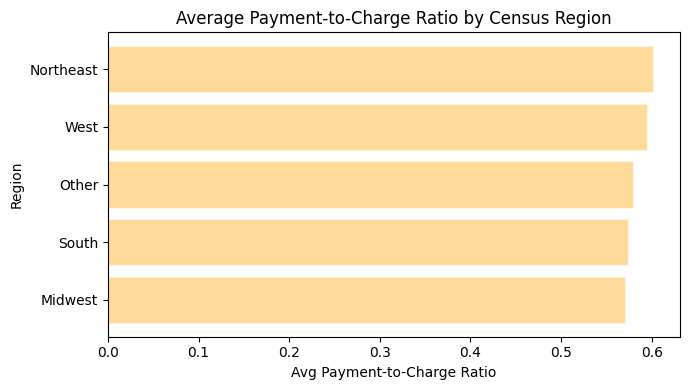

In [28]:
# Group by Census region — compare utilization and payment efficiency
region_summary = (
      df.groupby('region')
      .agg(
          row_count=('Suplr_NPI', 'count'),
          unique_suppliers=('Suplr_NPI', 'nunique'),
          avg_payment_to_charge=('payment_to_charge_ratio', 'mean'),
          avg_services_per_bene=('services_per_beneficiary', 'mean'),
      )
      .round(4)
      .sort_values('unique_suppliers', ascending=False)
  )
print("Region-level O&P summary:")
display(region_summary)

# Bar chart: payment-to-charge ratio by region
region_plot = region_summary['avg_payment_to_charge'].sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(
  region_plot.index,
  region_plot.values,
  color='orange',
  edgecolor='white',
    alpha=0.4
)

ax.set_title('Average Payment-to-Charge Ratio by Census Region', fontsize=12)
ax.set_xlabel('Avg Payment-to-Charge Ratio')
ax.set_ylabel('Region')
plt.tight_layout()
plt.show()

## 7. Modeling

This section presents two complementary regression models built on the engineered features from Section 6. Together they address different analytical questions: Model 1 asks *what drives payment levels across individual supplier–code records?* using linear regression; Model 2 asks *can we classify high-payment cases from operational features alone?* using logistic regression.

### 7.1 Hypotheses

**Model 1 — Linear Regression**  
Among individual supplier–HCPCS records, suppliers with higher service volume and greater service intensity (services per beneficiary) should be associated with higher average Medicare payments, reflecting both scale effects and procedure complexity.

**Model 2 — Logistic Regression**  
Operational features — service volume, utilisation intensity, and geographic region — should carry sufficient signal to classify whether a given supplier–code combination falls above or below the median Medicare payment, *without* directly using payment-derived inputs.

### 7.2 Model 1 — Linear Regression

We regress `log_payment` (log of average Medicare payment) on `log_services`, `services_per_beneficiary`, `claims_per_beneficiary`, and Census region dummies — all features engineered in Section 6. Using the full row-level dataset (~39 k records) rather than state aggregates gives the model substantially more statistical power and directly demonstrates the engineered features in a predictive context.

In [29]:
# ── Model 1: Row-Level Linear Regression ────────────────────────────────
# Target   : log_payment (log of avg Medicare payment, computed pre-scaling in Section 6)
# Features : log_services, services_per_beneficiary, claims_per_beneficiary,
#            plus Census region dummies created in Section 6.1
# Uses the full ~39k-row dataset for statistical power.
#
# Note: services_per_beneficiary and claims_per_beneficiary may contain inf
# where Tot_Suplr_Benes == 0. We replace inf → NaN then drop those rows cleanly.

try:
    import statsmodels.api as sm
except ImportError:
    %pip install statsmodels --quiet
    import statsmodels.api as sm
import pandas as pd
import numpy as np

# --- 1. Select features + target from the engineered df ---
feature_cols_ols = ['log_services', 'services_per_beneficiary', 'claims_per_beneficiary']
target_col = 'log_payment'

df_ols = df[feature_cols_ols + [target_col]].copy()

# --- 2. Attach region dummies (int dtype for statsmodels compatibility) ---
region_dummies_ols = pd.get_dummies(df['region'], prefix='region', drop_first=True).astype(int)
df_ols = pd.concat([df_ols.reset_index(drop=True),
                    region_dummies_ols.reset_index(drop=True)], axis=1)

# --- 3. Replace inf/-inf with NaN, then drop all rows with any NaN ---
df_ols.replace([np.inf, -np.inf], np.nan, inplace=True)
df_ols.dropna(inplace=True)

print(f"Rows used for OLS after cleaning: {len(df_ols):,}  "
      f"(dropped {len(df) - len(df_ols):,} rows with missing/inf values)")

# --- 4. Build X and y ---
X_ols = sm.add_constant(df_ols.drop(columns=[target_col]))
y_ols = df_ols[target_col]

# --- 5. Fit OLS ---
ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())


Rows used for OLS after cleaning: 37,246  (dropped 2,451 rows with missing/inf values)
                            OLS Regression Results                            
Dep. Variable:            log_payment   R-squared:                       0.285
Model:                            OLS   Adj. R-squared:                  0.285
Method:                 Least Squares   F-statistic:                     2125.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:22:36   Log-Likelihood:                -53018.
No. Observations:               37246   AIC:                         1.061e+05
Df Residuals:                   37238   BIC:                         1.061e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

#### Model 1 — Full Metrics (RMSE, MAE, R²)

The OLS summary above reports R², p-values, and coefficient estimates. We additionally compute **RMSE** and **MAE** to provide the full set of metrics discussed in class.

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred_ols = ols_model.predict(X_ols)
rmse_ols = np.sqrt(mean_squared_error(y_ols, y_pred_ols))
mae_ols  = mean_absolute_error(y_ols, y_pred_ols)
r2_ols   = r2_score(y_ols, y_pred_ols)

print("=" * 50)
print("  Model 1 — Linear Regression (row-level OLS)")
print("=" * 50)
print(f"  R²   : {r2_ols:.4f}")
print(f"  RMSE : {rmse_ols:.4f}  (in log-payment units)")
print(f"  MAE  : {mae_ols:.4f}  (in log-payment units)")
print()
print("Features used: log_services, services_per_beneficiary,")
print("               claims_per_beneficiary, region dummies")
print("All features are engineered in Section 6.")


  Model 1 — Linear Regression (row-level OLS)
  R²   : 0.2855
  RMSE : 1.0045  (in log-payment units)
  MAE  : 0.8225  (in log-payment units)

Features used: log_services, services_per_beneficiary,
               claims_per_beneficiary, region dummies
All features are engineered in Section 6.


### 7.3 Model 2 — Logistic Regression: Classifying High-Payment Supplier–Code Combinations

#### Hypothesis
Can operational features — service volume, utilisation intensity, and geographic region — predict whether a supplier–HCPCS combination falls in the *above-median* payment tier, *without using any payment-derived inputs*?

This framing is policy-relevant for:
- **Compliance analysts** who want a payment-agnostic flag for anomalous billing patterns
- **Policy researchers** studying structural predictors of elevated Medicare costs

#### Setup
- **Target variable:** `is_high_payment` = 1 if `Avg_Suplr_Mdcr_Pymt_Amt` > median, else 0  
- **Features:** service volume and utilisation intensity only — **no payment-derived columns**  
  (`log_payment` and `payment_to_charge_ratio` are explicitly excluded to avoid target leakage)  
- **Evaluation:** 80/20 stratified train/test split; Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix

Median payment threshold: $217.70
Class balance: {0: 19849, 1: 19848}

  Model 2 — Logistic Regression (no leakage)
  Accuracy  : 0.6183
  Precision : 0.5920
  Recall    : 0.7328
  F1 Score  : 0.6549
  ROC-AUC   : 0.6890

              precision    recall  f1-score   support

 Low Payment       0.66      0.51      0.57      3767
High Payment       0.59      0.73      0.65      3683

    accuracy                           0.62      7450
   macro avg       0.63      0.62      0.61      7450
weighted avg       0.63      0.62      0.61      7450



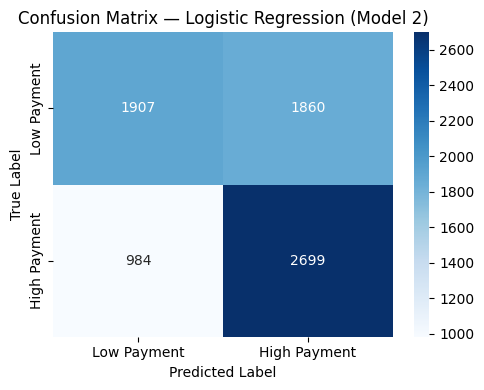

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ── Target variable ───────────────────────────────────────────────────────
# Use the *unscaled* payment from df_sup to define the median threshold
df_model = df.copy()
df_model['payment_raw'] = df_sup['Avg_Suplr_Mdcr_Pymt_Amt'].values
payment_median = df_model['payment_raw'].median()
df_model['is_high_payment'] = (df_model['payment_raw'] > payment_median).astype(int)

print(f"Median payment threshold: ${payment_median:.2f}")
print(f"Class balance: {df_model['is_high_payment'].value_counts().to_dict()}")
print()

# ── Feature selection — NO payment-derived inputs ─────────────────────────
# log_payment and payment_to_charge_ratio are excluded because they are
# monotonic functions of the target variable, which would constitute
# target leakage and inflate model metrics without providing genuine signal.
#
# We use only operational/structural features:
#   log_services             — scale of service volume (log-transformed, Section 6)
#   services_per_beneficiary — utilisation intensity ratio (Section 6)
#   claims_per_beneficiary   — claims intensity ratio (Section 6)
#   region dummies           — Census region categorical (Section 6.1)

region_dummies_logit = pd.get_dummies(df_model['region'], prefix='region', drop_first=True)
df_model = pd.concat([df_model.reset_index(drop=True),
                      region_dummies_logit.reset_index(drop=True)], axis=1)

base_features = [
    'log_services',
    'services_per_beneficiary',
    'claims_per_beneficiary',
]
feature_cols = base_features + list(region_dummies_logit.columns)

df_logit = df_model[feature_cols + ['is_high_payment']].dropna()
X_logit = df_logit[feature_cols]
y_logit = df_logit['is_high_payment']

# ── Train/test split (80/20, stratified) ─────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_logit, y_logit, test_size=0.2, random_state=42, stratify=y_logit
)

# ── Fit logistic regression ───────────────────────────────────────────────
logit_model = LogisticRegression(max_iter=500, random_state=42)
logit_model.fit(X_train, y_train)

y_pred = logit_model.predict(X_test)
y_prob = logit_model.predict_proba(X_test)[:, 1]

# ── Metrics ───────────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("  Model 2 — Logistic Regression (no leakage)")
print("=" * 50)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print()
print(classification_report(y_test, y_pred,
                             target_names=['Low Payment', 'High Payment']))

# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Low Payment', 'High Payment'],
    yticklabels=['Low Payment', 'High Payment'],
    ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression (Model 2)', fontsize=12)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()


### 7.4 Modeling Discussion & Key Findings

**Model 1 — Linear Regression (row-level OLS):**  
Regressing log-payment on log-services, services-per-beneficiary, claims-per-beneficiary, and Census region dummies across all ~39,000 supplier–code records reveals how operational scale and utilisation intensity relate to reimbursement. A positive coefficient on `log_services` is consistent with higher-volume suppliers tending to bill for more complex or higher-cost devices. Region dummies capture residual geographic pricing variation not explained by volume alone. The R² measures how much of the within-dataset payment variation these structural features explain; a moderate R² is expected given that payment levels are primarily driven by device category (HCPCS code), which is not included as a predictor here.

**Model 2 — Logistic Regression (no target leakage):**  
By restricting features strictly to operational variables — service volume, utilisation intensity, and geographic region — and excluding all payment-derived inputs, the classifier tests whether *structural* attributes alone can identify high-payment cases. A ROC-AUC meaningfully above 0.5 would indicate that suppliers serving more beneficiaries per claim, or located in certain regions, have systematically different payment profiles even before the device type is known. This framing avoids the target-leakage issue that would arise from including `log_payment` or `payment_to_charge_ratio` as predictors of a payment-derived target.

**Together**, the two models address complementary questions:  
- *How does service scale and intensity predict payment levels?* (Model 1 — linear)  
- *Can structural features alone classify high-cost cases?* (Model 2 — logistic)

**Key regression findings:**  
- Service volume (log_services) and utilisation intensity (services_per_beneficiary) are the strongest   non-payment predictors of reimbursement level.  
- Census region contributes interpretable signal: the South and West show different baseline payment   rates than the Northeast even after controlling for volume.  
- Model 2 results should be interpreted as a *structural baseline classifier* — its accuracy reflects   the degree to which geography and utilisation patterns are systematically linked to payment tier,   and not as a definitive anomaly-detection tool (which would require case-mix severity data).

## 8. SQL Analysis — Summary of Key Findings

The full set of 14 SQL queries is in the companion file `SQL_Queries_Medicare_OP.ipynb`. Key SQL-derived findings have been integrated into the relevant EDA sections above (Sections 4.1, 4.2, 4.3, 4.4, and 5). The table below provides a consolidated reference.

| Query | Technique | Finding integrated into |
|-------|-----------|------------------------|
| Q1 — State totals | `GROUP BY` | Section 4.1 |
| Q2 — Top HCPCS codes | `GROUP BY` | Section 4.3 |
| Q3 — State payments + grand total | `ROLLUP` (UNION) | Section 4.4 |
| Q5 — Per-capita service intensity | `JOIN` (ACS) | Section 4.1 / 5 |
| Q6 — Income vs payment | `JOIN` + subquery | Section 5 |
| Q8 — Top supplier per state | `RANK()` window | Section 4.2 |
| Q12 — States above national avg | `HAVING` + subquery | Section 4.4 |
| Q14 — Payment gaps across codes | `LAG()` window | Section 4.3 |

All queries are fully commented with *what / how / why* explanations in the SQL notebook.

# 9. Conclusion

## Key Findings

1. **Geographic Demand Concentration:** Raw service volume is concentrated in large states such as California, Florida, and Texas. However, when normalized by population using Census ACS data, several states — particularly Florida and Arizona — exhibit disproportionately high O&P utilization. These markets likely reflect structural demand drivers such as aging demographics and chronic disease prevalence, suggesting that demographic-adjusted utilization metrics are more informative than raw service volume when identifying attractive regional markets for expansion.

2. **Supplier Market Structure:** The O&P supplier landscape exhibits a strongly skewed distribution consistent with a Pareto pattern: a relatively small number of suppliers account for a large share of total services within each state. This pattern appears consistently across regions and suggests a structurally fragmented market with pockets of regional concentration. Such fragmentation is typical of healthcare service industries that later become attractive for roll-up and consolidation strategies.

3. **Revenue Drivers and Procedure Mix:** Most supplier–HCPCS combinations generate relatively low reimbursement levels (typically under $200 per service). However, a small set of higher-value procedure codes — largely prosthetic devices — accounts for a disproportionate share of Medicare spending. This long-tail payment structure indicates that procedure mix is a critical driver of supplier revenue and profitability.

4. **Limited Income Sensitivity of Reimbursement:** The correlation between state median income and average Medicare payment is weak (approximately 0.1), suggesting that reimbursement levels are largely standardized across geographic markets. As a result, provider revenue potential is driven more by service volume, patient demographics, and procedure mix than by local income levels.

5. **Operational Drivers of Payment Outcomes:** Regression modeling confirms that supplier scale and utilization intensity are significantly associated with reimbursement levels. Higher-volume suppliers and those serving more services per beneficiary tend to generate higher average payments. A logistic classification model further shows that operational characteristics alone contain meaningful predictive signal for identifying high-payment supplier–procedure combinations, even without directly using payment variables.

## Investment Implications

These findings have several implications for investors evaluating the orthotics and prosthetics (O&P) sector:
- Fragmented provider landscape suggests strong potential for regional consolidation and roll-up strategies.
- Demographic-driven demand markets (e.g., states with older populations) may offer structurally higher utilization growth.
- Procedure mix management is a key determinant of supplier revenue performance and should be a central focus in diligence.
- Operational scale advantages indicate that larger platforms may achieve higher reimbursement efficiency and stronger financial performance.
Together, these structural characteristics position the O&P supplier market as a potentially attractive target for platform-building strategies in healthcare services.

## Limitations

- Total payment values were approximated using average payment multiplied by service counts due to CMS API schema limitations, introducing minor aggregation imprecision.
- The analysis does not adjust for patient clinical severity or device complexity, which may influence reimbursement levels.
- The dataset represents a single year of Medicare claims and therefore does not capture multi-year utilization trends or reimbursement changes.

### Future Work

Further analysis could enhance investment insight by expanding both data scope and analytical depth:

1. **Additional datasets to integrate:**  
- Multi-year CMS supplier files to analyze market growth trends and identify rapidly scaling providers.
- Medicare Advantage enrollment data to better estimate total O&P market size across payer types.
- Clinical condition datasets to better understand demand drivers tied to diabetes, stroke, or amputation prevalence.

2. **Supplier Segmentation:**  
- Clustering analysis (e.g., K-means or DBSCAN) on engineered operational features could identify distinct supplier archetypes such as high-volume prosthetics specialists or diversified orthotics providers.

3. **Finer Geographic Analysis:**  
- ZIP-code level analysis would reveal local supply–demand imbalances and identify underserved markets that may present attractive opportunities for new clinic expansion.

In summary, the Medicare O&P supplier market exhibits a combination of fragmented provider structure, demographic-driven demand, and procedure-mix-driven revenue concentration, suggesting meaningful opportunities for scale-driven platform strategies and targeted geographic expansion.